In [1]:
!pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.1 MB/s eta 0:00:00


In [30]:
# read data

In [3]:
import os
import pandas as pd

path = "..."
data = []

for level in ['A1', 'A2', 'B1', 'B2']:
    folder_path = os.path.join(path, level)
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            with open(os.path.join(folder_path, filename), 'r', encoding='utf-8') as f:
                data.append({'text': f.read(), 'label': level})

df = pd.DataFrame(data)

In [4]:
print(len(df))

437


In [5]:
print(df.columns)

Index(['text', 'label'], dtype='object')


In [21]:
!pip install stop-words

from stop_words import get_stop_words

uk_stopwords = get_stop_words("ukrainian")

custom_words = ["бо", "із", "маю", "хочу", "хоче", "привіт", "ласка", "прошу"]
uk_stopwords.extend(custom_words)

In [22]:
print(uk_stopwords)

['або', 'адже', 'аж', 'але', 'ало', 'б', 'багато', 'без', 'безперервно', 'більш', 'більше', 'близько', 'був', 'буває', 'буде', 'будемо', 'будете', 'будеш', 'буду', 'будуть', 'будь', 'будь ласка', 'була', 'були', 'було', 'бути', 'в', 'важлива', 'важливе', 'важливий', 'важливі', 'вам', 'вами', 'вас', 'ваш', 'ваша', 'ваше', 'ваші', 'вгору', 'вдалині', 'весь', 'вже', 'ви', 'від', 'відсотків', 'він', 'вісім', 'вісімнадцятий', 'вісімнадцять', 'вміти', 'вниз', 'внизу', 'вона', 'вони', 'воно', 'восьмий', 'все', 'всею', 'всім', 'всіх', 'всього', 'всьому', 'всю', 'вся', 'втім', 'г', 'геть', 'говорив', 'давно', 'далеко', 'далі', 'даром', 'два', 'двадцятий', 'двадцять', 'дванадцятий', 'дванадцять', 'дві', 'двох', 'де', "дев'ятий", "дев'ятнадцятий", "дев'ятнадцять", "дев'ять", 'день', 'десятий', 'десять', 'дійсно', 'для', 'до', 'добре', 'довго', 'досить', 'другий', 'друго', 'дуже', 'дякую', 'е', 'є', 'ж', 'життя', 'з', 'за', 'завжди', 'зазвичай', 'зайнята', 'зайнятий', 'зайняті', 'зайнято', 'занадт

In [23]:
!pip install spacy
!python -m spacy download uk_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 61.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('uk_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [24]:
import re
import pandas as pd
import spacy

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

nlp = spacy.load("uk_core_news_sm", disable=["parser", "ner"])

def lemmatize_and_clean(text):
    doc = nlp(str(text).lower())
    lemmas = [token.lemma_ for token in doc if not token.is_punct]
    text = " ".join(lemmas)
    text = re.sub(r"[^a-zа-яіїєґ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Lemmatizing text...")
df["clean_text"] = df["text"].apply(lemmatize_and_clean)


embedding_model = SentenceTransformer("intfloat/multilingual-e5-base")

vectorizer_model = CountVectorizer(
    stop_words=uk_stopwords,
    ngram_range=(1, 2),
    min_df=3
)

umap_model = UMAP(
    n_neighbors=30,
    n_components=10,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(df["clean_text"])

topic_model = topic_model.reduce_topics(
    df["clean_text"],
    nr_topics=10
)

df["topic"] = topic_model.topics_

topic_model.visualize_barchart(top_n_topics=10)

Lemmatizing text...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-23 11:28:16,736 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

2026-04-23 11:36:12,483 - BERTopic - Embedding - Completed ✓
2026-04-23 11:36:12,486 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-23 11:36:14,111 - BERTopic - Dimensionality - Completed ✓
2026-04-23 11:36:14,112 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 11:36:14,150 - BERTopic - Cluster - Completed ✓
2026-04-23 11:36:14,156 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-23 11:36:14,361 - BERTopic - Representation - Completed ✓
2026-04-23 11:36:14,524 - BERTopic - Topic reduction - Reducing number of topics
2026-04-23 11:36:14,525 - BERTopic - Topic reduction - Number of topics (10) is equal or higher than the clustered topics(10).
2026-04-23 11:36:14,527 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-23 11:36:17,172 - BERTopic - Representation - Completed ✓


In [27]:
print(topic_model.get_topic_info())

print(df.groupby(["label", "topic"]).size())

fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=5)
fig_barchart.show()

   Topic  Count                                    Name  \
0     -1    159               -1_україна_свій_друг_піти   
1      0     48        0_свято_дівчина_страва_українець   
2      1     46              1_місто_київ_львов_україна   
3      2     31         2_аудиторія_студент_звати_зошит   
4      3     31           3_відділ_магазин_товар_купити   
5      4     27        4_дякувати_бувати_просити_добрий   
6      5     27  5_культура_технологія_система_професія   
7      6     26       6_університет_студент_читати_мова   
8      7     21               7_мама_тато_любити_бабуся   
9      8     21            8_щастя_чоловік_розмова_свій   

                                      Representation  \
0  [україна, свій, друг, піти, казати, можний, жи...   
1  [свято, дівчина, страва, українець, україна, н...   
2  [місто, київ, львов, україна, львівський, укра...   
3  [аудиторія, студент, звати, зошит, кімната, чи...   
4  [відділ, магазин, товар, купити, місто, можний...   
5  [дякувати, 

In [29]:
topic_labels = {
    0: "Culture & Traditions",
    1: "Geography/Cities",
    2: "Learning Environment",
    3: "Shopping",
    4: "Communication/Etiquette",
    5: "Technology & Profession",
    6: "Academic Life",
    7: "Family",
    8: "Social/Abstract"
}
topic_model.set_topic_labels(topic_labels)
topic_model.visualize_barchart(custom_labels=True)

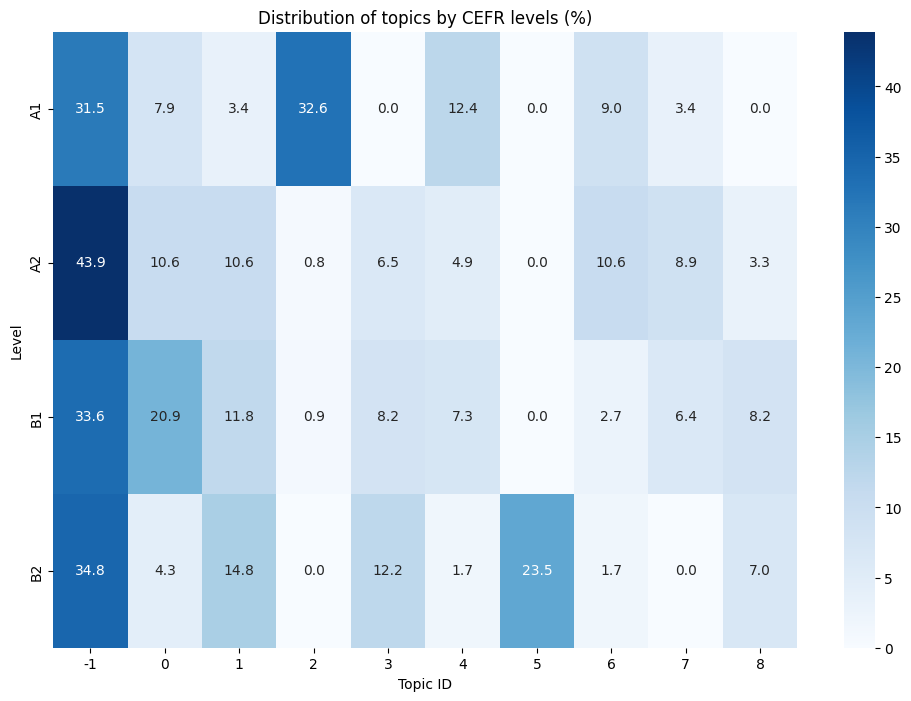

In [28]:
# Heatmap
topic_distribution = pd.crosstab(df['label'], df['topic'], normalize='index') * 100

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(topic_distribution, annot=True, fmt=".1f", cmap="Blues")
plt.title("Distribution of topics by CEFR levels (%)")
plt.xlabel("Topic ID")
plt.ylabel("Level")
plt.show()